# Fibrosis Progression Rates: Data Strategy & NHANES Pseudo-Cohort Analysis

**Goal:** Identify publicly available data to estimate age-, sex-, and race-specific
progression rates for liver fibrosis (measured by FIB-4 or LSM), for use in a
microsimulation.

## Approach

1. Review published longitudinal fibrosis progression estimates
2. Survey available data sources (open vs controlled access)
3. Implement a **pseudo-cohort analysis** using NHANES repeated cross-sections (1999–2018)
   to estimate how FIB-4 changes with age, stratified by sex and race/ethnicity

---
## 1. Literature Review: Published Fibrosis Progression Rates

### 1a. Singh et al. (2015) — Paired Biopsy Meta-Analysis

**"Fibrosis Progression in Nonalcoholic Fatty Liver vs Nonalcoholic Steatohepatitis:
A Systematic Review and Meta-analysis of Paired-Biopsy Studies"**
([PMC4208976](https://pmc.ncbi.nlm.nih.gov/articles/PMC4208976/))

- 11 cohort studies, 411 patients (150 NAFL, 261 NASH), 2,145.5 person-years
- **Annual fibrosis progression rate (from stage 0):**
  - NAFL: **0.07 stages/year** (95% CI 0.02–0.11) → 1 stage per 14.3 years
  - NASH: **0.14 stages/year** (95% CI 0.07–0.21) → 1 stage per 7.1 years
  - Overall NAFLD: **0.13 stages/year** (95% CI 0.07–0.18) → 1 stage per 7.7 years
- 33.6% progressed, 43.1% stable, 22.3% improved
- **Limitation:** Insufficient data to stratify by age, sex, or race

### 1b. Hagström et al. (2020) — AMORIS Cohort, Repeated FIB-4

**"Repeated FIB-4 measurements can help identify individuals at risk of severe liver disease"**
([PMID: 32621944](https://pubmed.ncbi.nlm.nih.gov/32621944/))

- Swedish AMORIS cohort, 40,729 individuals with 2 FIB-4 measurements within 5 years
- Mean interval between measurements: 2.4 years
- 581 severe liver disease events over 613,376 person-years (median 16.2y follow-up)
- Showed that FIB-4 category changes (low→intermediate→high) predict severe liver disease
- **Limitation:** Individual-level data not publicly available; limited age/sex/race stratification in the paper

### 1c. Serial MRE Studies (Mayo Clinic)

**"Change in Serial Liver Stiffness Measurement by MR Elastography and Outcomes in NAFLD"**
([PMC9712594](https://pmc.ncbi.nlm.nih.gov/articles/PMC9712594/))

- Used ≥19% LSM change (QIBA consensus) to define progression/regression
- Clinical cohort, not population-based; data not publicly available

### 1d. NORIP (2025) — Age/Sex-Specific FIB-4 Reference Values

**"Age- and sex-specific reference values for FIB-4 derived from the Nordic Reference
Interval Project"**
([Tandfonline](https://www.tandfonline.com/doi/full/10.1080/00365513.2025.2559352))

- 1,161 healthy subjects from Denmark, Finland, Iceland, Sweden
- Established that age is the dominant driver of FIB-4 in healthy populations
- >60y: 7.5% of females and 18.2% of males above FIB-4 >2.67
- Useful for calibrating the "background" age-related FIB-4 increase vs pathological progression

---
## 2. Data Source Comparison

| Source | Data Type | Fibrosis Measure | Longitudinal? | Access | Feasibility |
|--------|----------|-----------------|---------------|--------|-------------|
| **NHANES 1999–2018** | Repeated cross-sections | FIB-4 (all 10 cycles) | Pseudo-cohort only | **Open/public** | ★★★★★ |
| **NHANES 2017–18 + 2021–22** | Repeated cross-sections | LSM kPa + CAP dB/m (FibroScan) | Pseudo-cohort (2 cycles) | **Open/public** | ★★★★☆ |
| **EPIC Cosmos** | Longitudinal EHR (~280M patients) | FIB-4 from repeated labs; ICD fibrosis/cirrhosis codes | **True longitudinal** | Institutional access | ★★★★☆ |
| **NIH All of Us** | EHR + surveys | FIB-4 from labs (AST, ALT, platelets) | True longitudinal | Controlled (Researcher Workbench) | ★★★☆☆ |
| **UK Biobank** | MRI imaging | cT1 (corrected T1) as fibrosis proxy, not direct LSM | Repeat imaging starting | Controlled (application) | ★★☆☆☆ |
| **NIDDK NASH CRN** | Clinical trial | Paired biopsies, FIB-4, LSM | True longitudinal | Controlled (IRB + DUA) | ★★☆☆☆ |
| **Singh meta-analysis** | Published estimates | Biopsy stages | Summary rates only | **Open** (paper) | ★★★★☆ |

### Recommendation: NHANES Pseudo-Cohort + Published Calibration

**Primary open-data approach:** Use NHANES 1999–2018 (10 cycles, ~36,000 adults with
complete FIB-4 labs) as a **pseudo-cohort** for FIB-4 trajectories by age/sex/race.
For LSM, use the 2017–18 and 2021–22 cycles together (see notebook 02).

**Calibration:** Compare pseudo-cohort slopes against:
- Singh et al. paired-biopsy progression rates (0.07–0.14 stages/year)
- NORIP reference values for healthy population FIB-4 by age/sex

**Future enhancement (institutional access):** EPIC Cosmos offers true individual-level
FIB-4 trajectories from repeated EHR labs at massive scale — the ideal engine for a
Markov transition model of fibrosis progression (see notebook 02, section 8).

---
## 3. NHANES Pseudo-Cohort Analysis

### Method

NHANES surveys a nationally representative sample every 2 years. While no individual
is measured twice, we can track **birth cohorts** across cycles:

- People born 1940–1944 were aged ~55–60 in 1999–2000, ~57–62 in 2001–2002, ..., ~73–78 in 2017–2018
- By computing the median FIB-4 for each birth cohort × cycle, we get a synthetic
  longitudinal trajectory
- Stratifying by sex and race/ethnicity reveals differential progression rates

### Limitation

This captures the **population-level age trajectory** of FIB-4, which conflates:
1. True biological aging effects on FIB-4 components (platelets decline, AST rises)
2. Actual fibrosis progression
3. Survivor bias (sicker individuals die, leaving healthier survivors)
4. Secular trends (obesity epidemic → more NAFLD over calendar time)

Despite these limitations, the pseudo-cohort approach provides the best available
population-level estimate of FIB-4 trajectory from open data.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

DERIVED = os.path.abspath(os.path.join('..', 'data', 'derived'))

### 3a. Load all NHANES cycles and compute FIB-4

In [2]:
CYCLES = [
    '1999_2000', '2001_2002', '2003_2004', '2005_2006', '2007_2008',
    '2009_2010', '2011_2012', '2013_2014', '2015_2016', '2017_2018',
]

# Race/ethnicity mapping from RIDRETH1
RACE_MAP = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    5: 'Other/Multi-Racial',
}

frames = []
for cyc in CYCLES:
    path = os.path.join(DERIVED, f'{cyc}.parquet')
    df = pd.read_parquet(path)
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
print(f'Total records: {len(all_df):,}')

# Compute FIB-4 = (Age × AST) / (Platelets × sqrt(ALT))
# Platelets in NHANES are in 1000 cells/µL
mask = (all_df['AST'] > 0) & (all_df['ALT'] > 0) & (all_df['PLATELETS'] > 0) & (all_df['AGE'] >= 35)
df = all_df[mask].copy()
df['FIB4'] = (df['AGE'] * df['AST']) / (df['PLATELETS'] * np.sqrt(df['ALT']))

# Parse cycle info
df['CYCLE_START'] = df['CYCLE'].str.split('-').str[0].astype(int)
df['CYCLE_MID'] = df['CYCLE_START'] + 1  # midpoint of 2-year cycle

# Birth year (approximate)
df['BIRTH_YEAR'] = df['CYCLE_MID'] - df['AGE']

# 5-year birth cohort bins
df['BIRTH_COHORT'] = (df['BIRTH_YEAR'] // 5) * 5

# Sex label
df['SEX'] = df['FEMALE'].map({0: 'Male', 1: 'Female'})

# Race/ethnicity label
df['RACE'] = df['RIDRETH1'].map(RACE_MAP)

# FIB-4 risk categories
df['FIB4_CAT'] = pd.cut(df['FIB4'], bins=[0, 1.30, 2.67, np.inf],
                         labels=['Low (<1.30)', 'Intermediate (1.30-2.67)', 'High (>2.67)'])

print(f'Adults ≥35 with complete FIB-4 data: {len(df):,}')
print(f'Birth year range: {df["BIRTH_YEAR"].min():.0f}–{df["BIRTH_YEAR"].max():.0f}')
print(f'\nFIB-4 summary:')
display(df['FIB4'].describe())
print(f'\nFIB-4 risk categories:')
display(df['FIB4_CAT'].value_counts().sort_index())

Total records: 59,064


Adults ≥35 with complete FIB-4 data: 36,120
Birth year range: 1915–1983

FIB-4 summary:


count    36120.000000
mean         1.348666
std          0.898095
min          0.144553
25%          0.829855
50%          1.158219
75%          1.631481
max         37.947332
Name: FIB4, dtype: float64


FIB-4 risk categories:


FIB4_CAT
Low (<1.30)                 21442
Intermediate (1.30-2.67)    12873
High (>2.67)                 1805
Name: count, dtype: int64

### 3b. FIB-4 distribution by age group (cross-sectional)

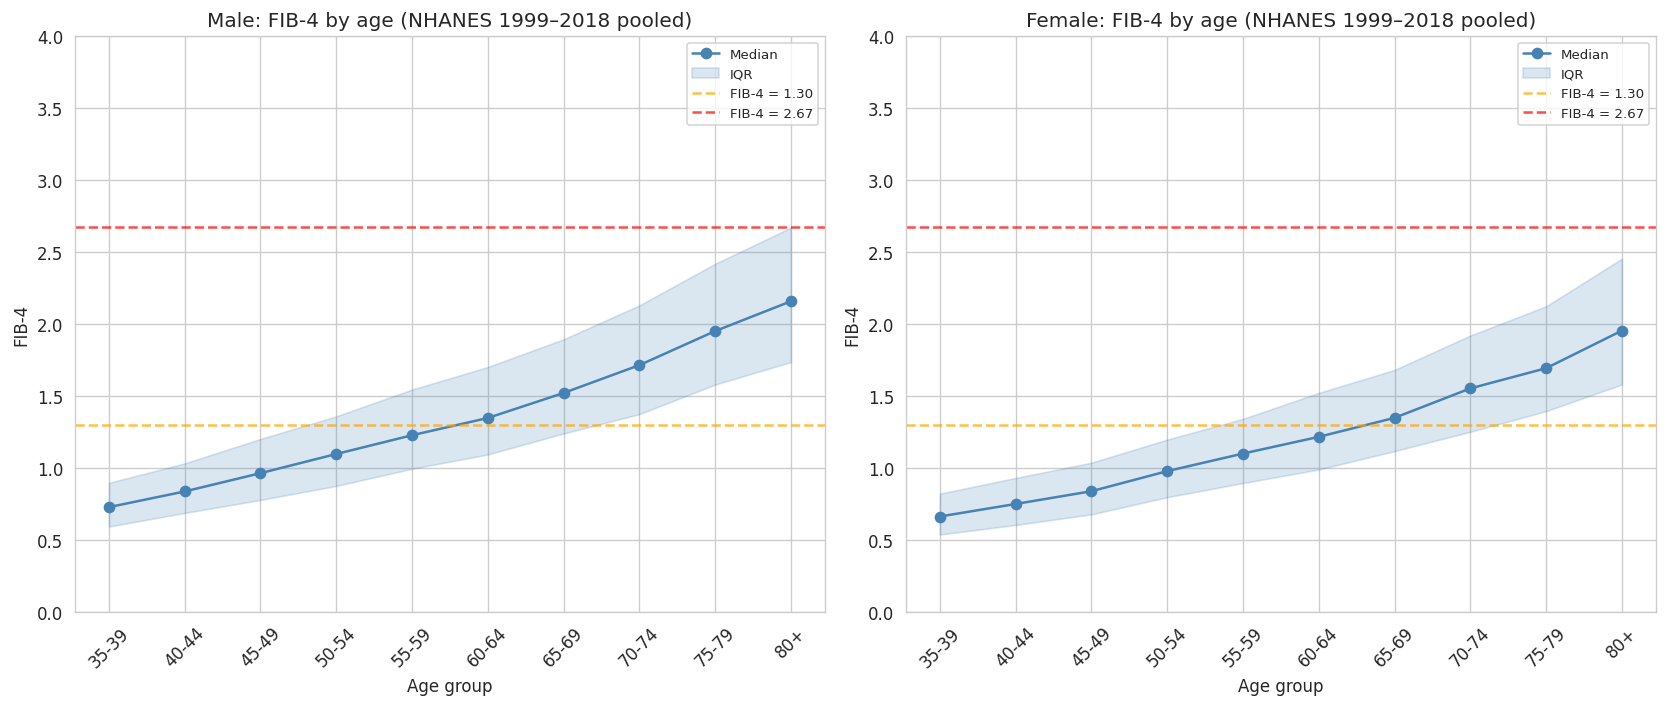

In [3]:
# Age bins
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[34, 39, 44, 49, 54, 59, 64, 69, 74, 79, 120],
                          labels=['35-39','40-44','45-49','50-54','55-59',
                                  '60-64','65-69','70-74','75-79','80+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Median FIB-4 by age group and sex
for ax, sex in zip(axes, ['Male', 'Female']):
    subset = df[df['SEX'] == sex]
    stats_tbl = subset.groupby('AGE_GROUP')['FIB4'].agg(['median', 'mean',
        lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats_tbl.columns = ['AGE_GROUP', 'median', 'mean', 'q25', 'q75']

    ax.plot(range(len(stats_tbl)), stats_tbl['median'], 'o-', color='steelblue', label='Median')
    ax.fill_between(range(len(stats_tbl)), stats_tbl['q25'], stats_tbl['q75'],
                     alpha=0.2, color='steelblue', label='IQR')
    ax.axhline(1.30, color='orange', ls='--', alpha=0.7, label='FIB-4 = 1.30')
    ax.axhline(2.67, color='red', ls='--', alpha=0.7, label='FIB-4 = 2.67')
    ax.set_xticks(range(len(stats_tbl)))
    ax.set_xticklabels(stats_tbl['AGE_GROUP'], rotation=45)
    ax.set_xlabel('Age group')
    ax.set_ylabel('FIB-4')
    ax.set_title(f'{sex}: FIB-4 by age (NHANES 1999–2018 pooled)')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()

### 3c. Pseudo-cohort trajectories: tracking birth cohorts across NHANES cycles

In [4]:
# Compute median FIB-4 for each birth cohort × cycle × sex
pseudo = df.groupby(['BIRTH_COHORT', 'CYCLE_MID', 'SEX']).agg(
    fib4_median=('FIB4', 'median'),
    fib4_mean=('FIB4', 'mean'),
    fib4_q25=('FIB4', lambda x: x.quantile(0.25)),
    fib4_q75=('FIB4', lambda x: x.quantile(0.75)),
    age_median=('AGE', 'median'),
    n=('FIB4', 'count'),
).reset_index()

# Filter to cohorts with at least 3 cycles and ≥30 people per cell
pseudo = pseudo[pseudo['n'] >= 30]
cohort_counts = pseudo.groupby(['BIRTH_COHORT', 'SEX']).size().reset_index(name='n_cycles')
good_cohorts = cohort_counts[cohort_counts['n_cycles'] >= 3]
pseudo = pseudo.merge(good_cohorts[['BIRTH_COHORT', 'SEX']], on=['BIRTH_COHORT', 'SEX'])

print(f'Birth cohorts with ≥3 cycles and ≥30 per cell:')
for sex in ['Male', 'Female']:
    cohorts = sorted(pseudo[pseudo['SEX'] == sex]['BIRTH_COHORT'].unique())
    print(f'  {sex}: {cohorts}')

Birth cohorts with ≥3 cycles and ≥30 per cell:
  Male: [np.float64(1915.0), np.float64(1920.0), np.float64(1925.0), np.float64(1930.0), np.float64(1935.0), np.float64(1940.0), np.float64(1945.0), np.float64(1950.0), np.float64(1955.0), np.float64(1960.0), np.float64(1965.0), np.float64(1970.0), np.float64(1975.0)]
  Female: [np.float64(1915.0), np.float64(1920.0), np.float64(1925.0), np.float64(1930.0), np.float64(1935.0), np.float64(1940.0), np.float64(1945.0), np.float64(1950.0), np.float64(1955.0), np.float64(1960.0), np.float64(1965.0), np.float64(1970.0), np.float64(1975.0)]


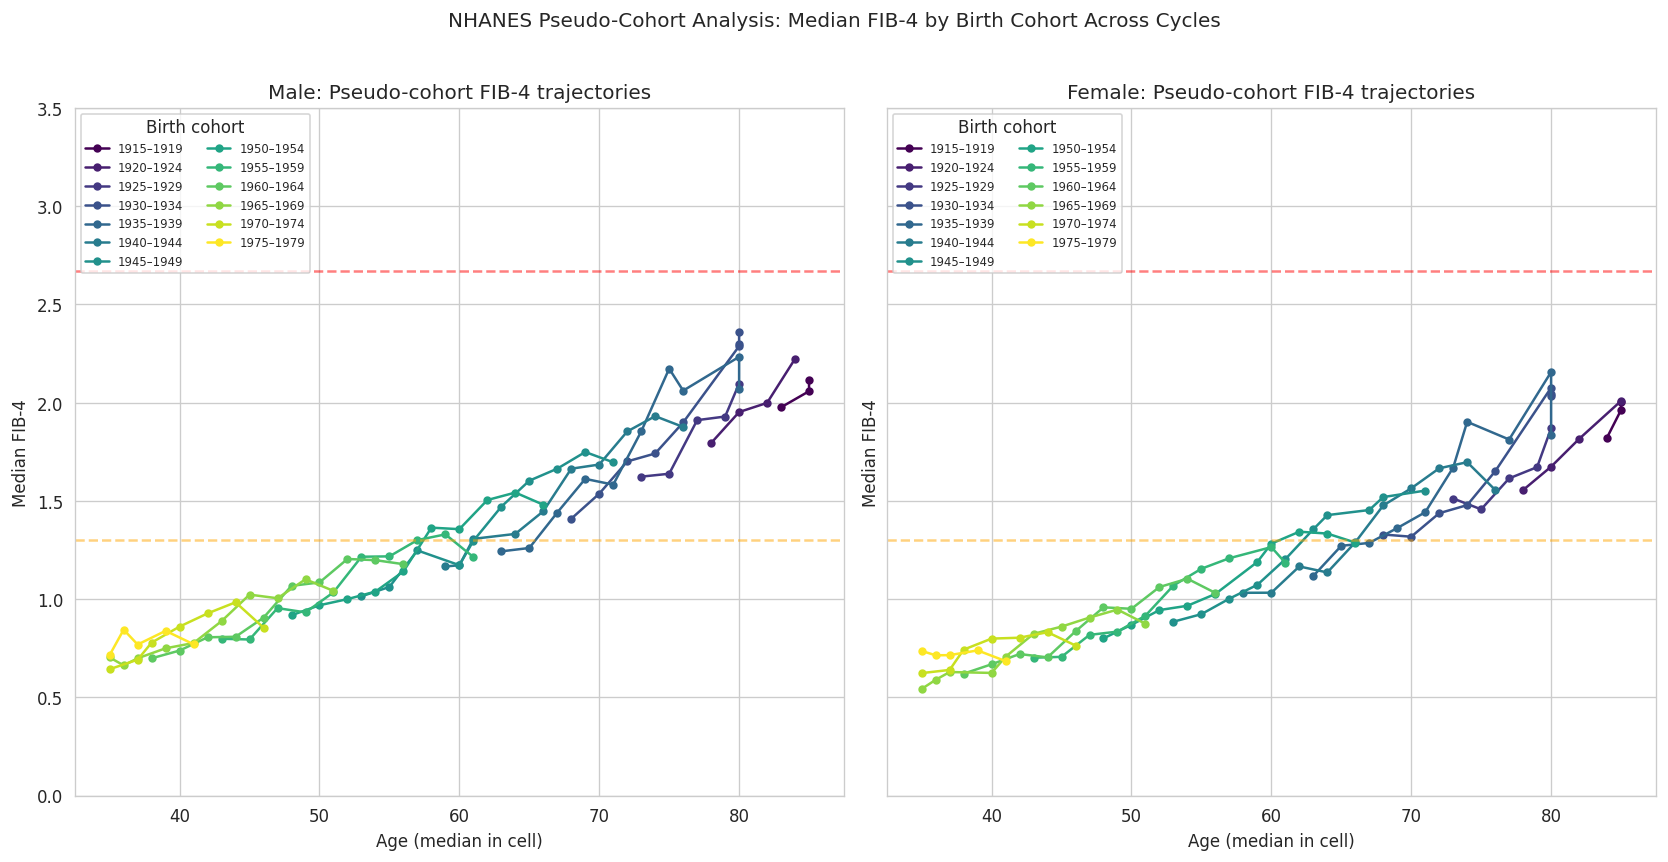

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

for ax, sex in zip(axes, ['Male', 'Female']):
    subset = pseudo[pseudo['SEX'] == sex].sort_values(['BIRTH_COHORT', 'CYCLE_MID'])
    cohorts = sorted(subset['BIRTH_COHORT'].unique())
    cmap = plt.cm.viridis(np.linspace(0, 1, len(cohorts)))

    for i, bc in enumerate(cohorts):
        cdata = subset[subset['BIRTH_COHORT'] == bc]
        ax.plot(cdata['age_median'], cdata['fib4_median'], 'o-',
                color=cmap[i], label=f'{int(bc)}–{int(bc+4)}', markersize=4)

    ax.axhline(1.30, color='orange', ls='--', alpha=0.5)
    ax.axhline(2.67, color='red', ls='--', alpha=0.5)
    ax.set_xlabel('Age (median in cell)')
    ax.set_ylabel('Median FIB-4')
    ax.set_title(f'{sex}: Pseudo-cohort FIB-4 trajectories')
    ax.legend(title='Birth cohort', fontsize=7, ncol=2, loc='upper left')
    ax.set_ylim(0, 3.5)

plt.suptitle('NHANES Pseudo-Cohort Analysis: Median FIB-4 by Birth Cohort Across Cycles',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 3d. Estimate annual FIB-4 change rate by age, sex, and race

In [6]:
# For each birth cohort × sex, fit a linear regression of median FIB-4 vs age
# The slope gives the estimated annual FIB-4 change

slopes = []
for sex in ['Male', 'Female']:
    subset = pseudo[pseudo['SEX'] == sex]
    for bc in sorted(subset['BIRTH_COHORT'].unique()):
        cdata = subset[subset['BIRTH_COHORT'] == bc].sort_values('CYCLE_MID')
        if len(cdata) < 3:
            continue
        slope, intercept, r, p, se = stats.linregress(cdata['age_median'], cdata['fib4_median'])
        age_range = f"{cdata['age_median'].min():.0f}–{cdata['age_median'].max():.0f}"
        slopes.append({
            'sex': sex,
            'birth_cohort': f"{int(bc)}–{int(bc+4)}",
            'age_range_observed': age_range,
            'n_cycles': len(cdata),
            'slope_per_year': slope,
            'intercept': intercept,
            'r_squared': r**2,
            'p_value': p,
        })

slopes_df = pd.DataFrame(slopes)
print('Annual FIB-4 change rate by birth cohort and sex:')
print('(slope = estimated change in median FIB-4 per year of aging)\n')
display(slopes_df.round(4))

Annual FIB-4 change rate by birth cohort and sex:
(slope = estimated change in median FIB-4 per year of aging)



,sex,birth_cohort,age_range_observed,n_cycles,slope_per_year,intercept,r_squared,p_value
0,Male,1915–1919,83–85,3,0.0547,-2.5650,0.8389,0.2629
1,Male,1920–1924,78–84,4,0.0667,-3.4069,0.9438,0.0285
2,Male,1925–1929,73–80,5,0.0677,-3.3555,0.9009,0.0137
3,Male,1930–1934,68–80,8,0.0766,-3.8391,0.9767,0.0000
4,Male,1935–1939,63–80,10,0.0601,-2.5679,0.9129,0.0000
5,Male,1940–1944,59–76,10,0.0481,-1.6758,0.9573,0.0000
6,Male,1945–1949,53–71,10,0.0439,-1.3289,0.9298,0.0000
7,Male,1950–1954,48–66,10,0.0387,-0.9752,0.9288,0.0000
8,Male,1955–1959,43–61,10,0.0311,-0.5366,0.8691,0.0001
9,Male,1960–1964,38–56,10,0.0319,-0.5285,0.9375,0.0000


In [7]:
# Summary: mean slope by sex
print('Mean annual FIB-4 change (median) by sex:')
summary = slopes_df.groupby('sex')['slope_per_year'].agg(['mean', 'std', 'count'])
display(summary.round(4))

Mean annual FIB-4 change (median) by sex:


,mean,std,count
sex,,,
Female,0.0468,0.0394,13
Male,0.0445,0.0203,13


In [8]:
# Now stratify by race/ethnicity
# Compute median FIB-4 for each birth cohort × cycle × sex × race
pseudo_race = df.groupby(['BIRTH_COHORT', 'CYCLE_MID', 'SEX', 'RACE']).agg(
    fib4_median=('FIB4', 'median'),
    age_median=('AGE', 'median'),
    n=('FIB4', 'count'),
).reset_index()

# Filter: need ≥20 per cell and ≥3 cycles
pseudo_race = pseudo_race[pseudo_race['n'] >= 20]
race_counts = pseudo_race.groupby(['BIRTH_COHORT', 'SEX', 'RACE']).size().reset_index(name='n_cycles')
good_race = race_counts[race_counts['n_cycles'] >= 3]
pseudo_race = pseudo_race.merge(good_race[['BIRTH_COHORT', 'SEX', 'RACE']],
                                 on=['BIRTH_COHORT', 'SEX', 'RACE'])

# Fit slopes by sex × race
race_slopes = []
for (sex, race), grp in pseudo_race.groupby(['SEX', 'RACE']):
    for bc in sorted(grp['BIRTH_COHORT'].unique()):
        cdata = grp[grp['BIRTH_COHORT'] == bc].sort_values('CYCLE_MID')
        if len(cdata) < 3:
            continue
        slope, intercept, r, p, se = stats.linregress(cdata['age_median'], cdata['fib4_median'])
        race_slopes.append({
            'sex': sex, 'race': race,
            'birth_cohort': f"{int(bc)}–{int(bc+4)}",
            'slope_per_year': slope,
            'r_squared': r**2,
            'n_cycles': len(cdata),
        })

race_slopes_df = pd.DataFrame(race_slopes)

print('Mean annual FIB-4 change by sex and race/ethnicity:')
race_summary = race_slopes_df.groupby(['sex', 'race'])['slope_per_year'].agg(['mean', 'std', 'count'])
display(race_summary.round(4))

Mean annual FIB-4 change by sex and race/ethnicity:


mean     std  count
sex    race                                     
Female Mexican American    0.0341  0.0215     10
       Non-Hispanic Black  0.0352  0.0227     11
       Non-Hispanic White  0.0390  0.0236     13
       Other Hispanic      0.0248  0.0244      8
       Other/Multi-Racial -0.0005  0.0110      7
Male   Mexican American    0.0367  0.0228     11
       Non-Hispanic Black  0.0337  0.0239     10
       Non-Hispanic White  0.0479  0.0342     13
       Other Hispanic      0.0323  0.0143      6
       Other/Multi-Racial  0.0161  0.0192      7

### 3e. Prevalence of elevated FIB-4 by age group, sex, and race

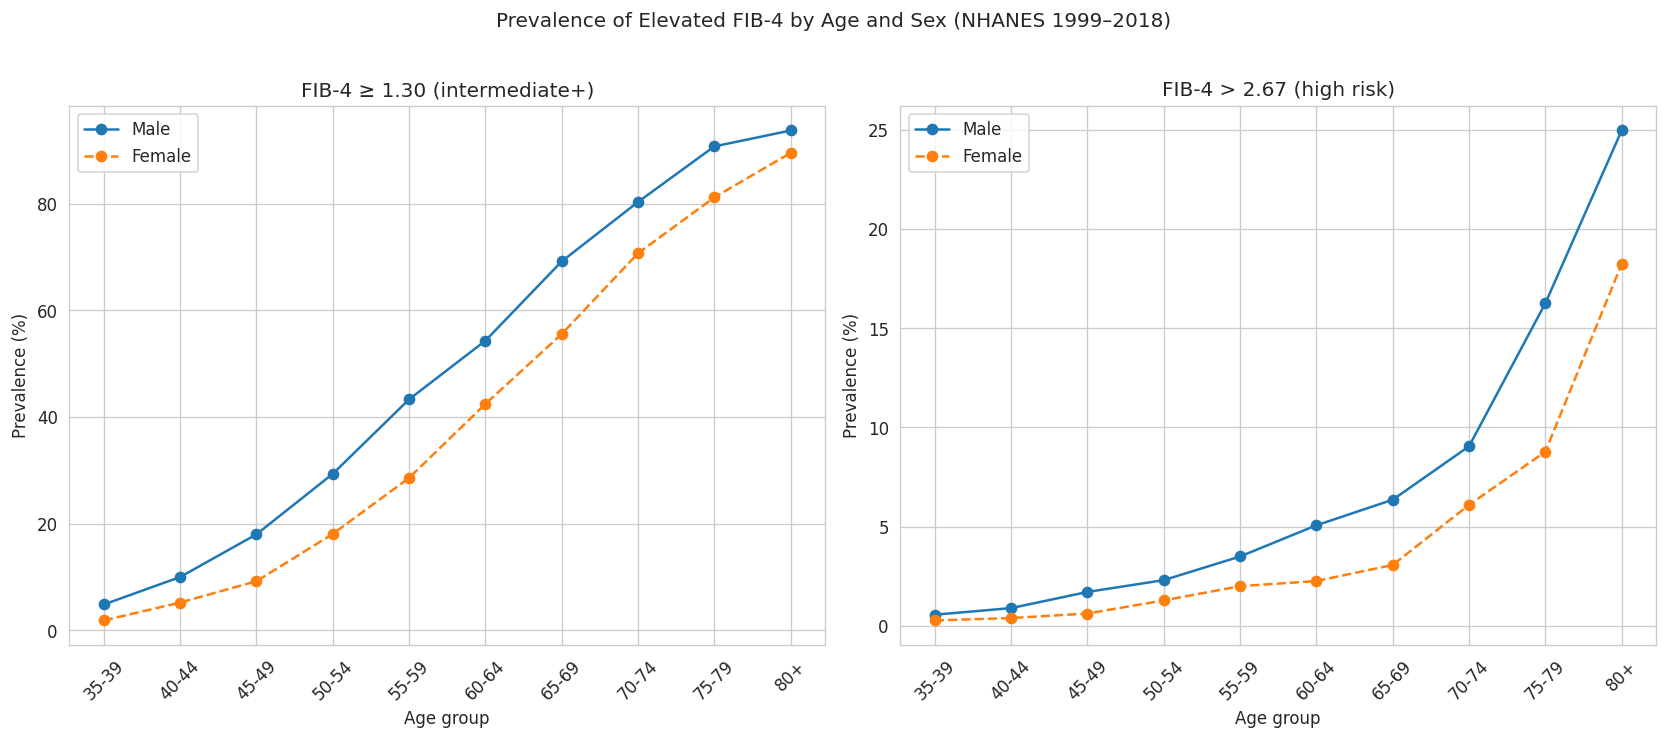

In [9]:
# Fraction with FIB-4 > 1.30 and > 2.67 by age group and sex
prev = df.groupby(['AGE_GROUP', 'SEX']).apply(
    lambda g: pd.Series({
        'n': len(g),
        'pct_intermediate_plus': (g['FIB4'] >= 1.30).mean() * 100,
        'pct_high': (g['FIB4'] >= 2.67).mean() * 100,
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label in [
    (axes[0], 'pct_intermediate_plus', 'FIB-4 ≥ 1.30 (intermediate+)'),
    (axes[1], 'pct_high', 'FIB-4 > 2.67 (high risk)'),
]:
    for sex, ls in [('Male', '-'), ('Female', '--')]:
        sub = prev[prev['SEX'] == sex]
        ax.plot(range(len(sub)), sub[metric], f'o{ls}', label=sex)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['AGE_GROUP'], rotation=45)
    ax.set_xlabel('Age group')
    ax.set_ylabel('Prevalence (%)')
    ax.set_title(label)
    ax.legend()

plt.suptitle('Prevalence of Elevated FIB-4 by Age and Sex (NHANES 1999–2018)', y=1.02)
plt.tight_layout()
plt.show()

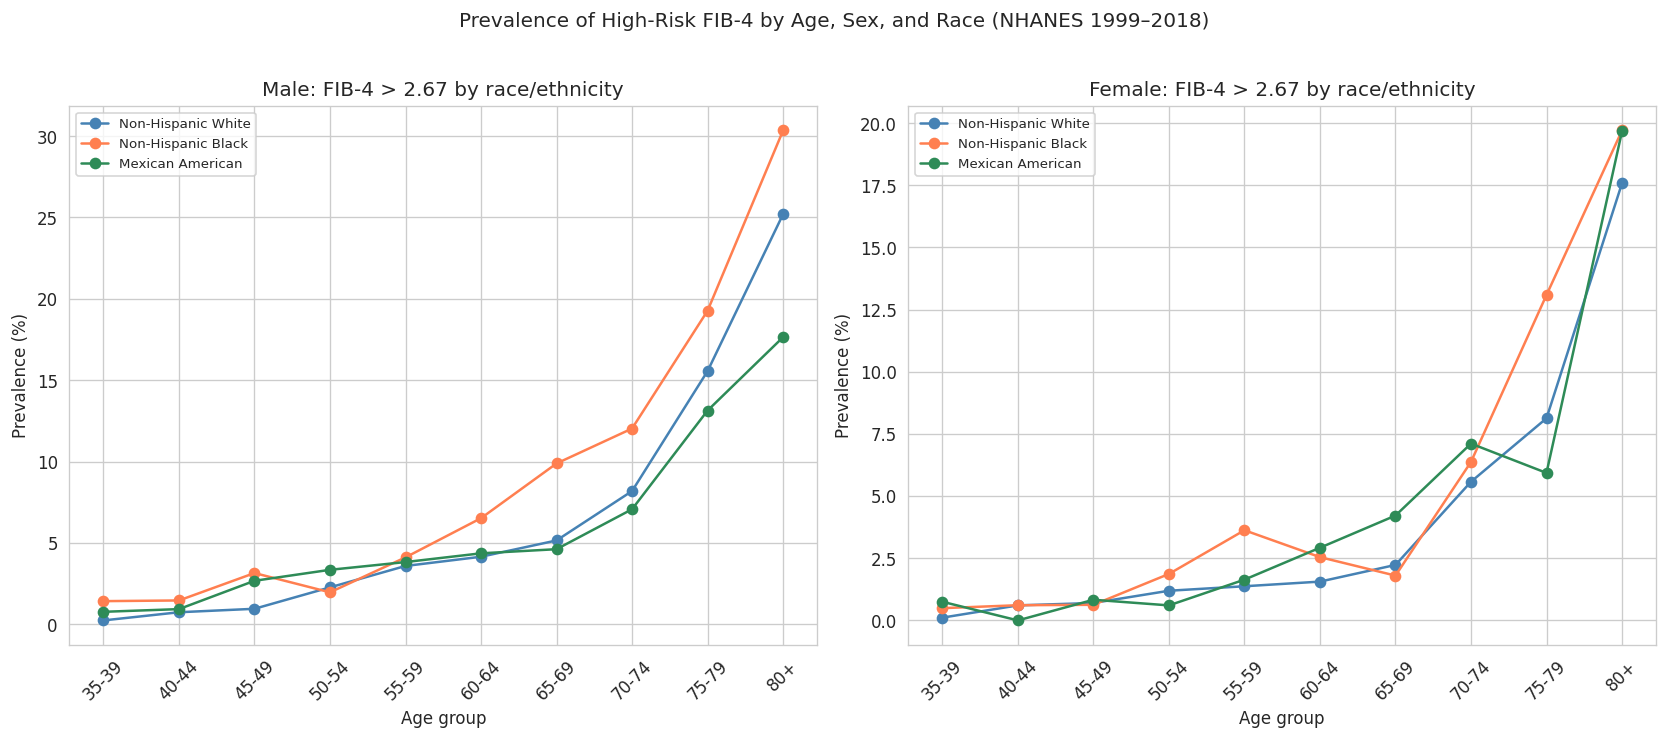

In [10]:
# Prevalence by age group, sex, and race (for the three largest groups)
main_races = ['Non-Hispanic White', 'Non-Hispanic Black', 'Mexican American']
prev_race = df[df['RACE'].isin(main_races)].groupby(['AGE_GROUP', 'SEX', 'RACE']).apply(
    lambda g: pd.Series({
        'n': len(g),
        'pct_high': (g['FIB4'] >= 2.67).mean() * 100,
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sex in zip(axes, ['Male', 'Female']):
    for race, color in zip(main_races, ['steelblue', 'coral', 'seagreen']):
        sub = prev_race[(prev_race['SEX'] == sex) & (prev_race['RACE'] == race)]
        ax.plot(range(len(sub)), sub['pct_high'], 'o-', color=color, label=race)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['AGE_GROUP'], rotation=45)
    ax.set_xlabel('Age group')
    ax.set_ylabel('Prevalence (%)')
    ax.set_title(f'{sex}: FIB-4 > 2.67 by race/ethnicity')
    ax.legend(fontsize=8)

plt.suptitle('Prevalence of High-Risk FIB-4 by Age, Sex, and Race (NHANES 1999–2018)', y=1.02)
plt.tight_layout()
plt.show()

### 3f. Export progression rate estimates for simulation use

In [11]:
# Save the slope estimates
slopes_df.to_csv('outputs/fib4_annual_change_by_cohort_sex.csv', index=False)
race_slopes_df.to_csv('outputs/fib4_annual_change_by_cohort_sex_race.csv', index=False)

# Save the prevalence tables
prev.to_csv('outputs/fib4_prevalence_by_age_sex.csv', index=False)
prev_race.to_csv('outputs/fib4_prevalence_by_age_sex_race.csv', index=False)

# Summary table for simulation parameters
print('Summary slope estimates for simulation (annual change in median FIB-4):')
print()
sim_params = slopes_df.groupby('sex')['slope_per_year'].agg(['mean', 'std']).round(4)
sim_params.columns = ['mean_annual_fib4_change', 'sd_annual_fib4_change']
display(sim_params)

print()
print('By sex and race/ethnicity:')
sim_race = race_slopes_df.groupby(['sex', 'race'])['slope_per_year'].agg(['mean', 'std']).round(4)
sim_race.columns = ['mean_annual_fib4_change', 'sd_annual_fib4_change']
display(sim_race)

print('\nFiles saved to outputs/')

Summary slope estimates for simulation (annual change in median FIB-4):



,mean_annual_fib4_change,sd_annual_fib4_change
sex,,
Female,0.0468,0.0394
Male,0.0445,0.0203



By sex and race/ethnicity:


mean_annual_fib4_change  sd_annual_fib4_change
sex    race                                                              
Female Mexican American                     0.0341                 0.0215
       Non-Hispanic Black                   0.0352                 0.0227
       Non-Hispanic White                   0.0390                 0.0236
       Other Hispanic                       0.0248                 0.0244
       Other/Multi-Racial                  -0.0005                 0.0110
Male   Mexican American                     0.0367                 0.0228
       Non-Hispanic Black                   0.0337                 0.0239
       Non-Hispanic White                   0.0479                 0.0342
       Other Hispanic                       0.0323                 0.0143
       Other/Multi-Racial                   0.0161                 0.0192


Files saved to outputs/


---
## 4. Discussion & Next Steps

### What this analysis provides

- **Population-level FIB-4 trajectories** by age, sex, and race from NHANES pseudo-cohorts
- **Annual FIB-4 change rates** that can parameterize a simulation model
- **Age/sex/race-specific prevalence** of elevated FIB-4 for initializing simulated populations

### Caveats for simulation use

1. **FIB-4 is not fibrosis.** FIB-4 increases with age even in healthy people (age is in the
   numerator, platelets decline with age). The pseudo-cohort slope captures both biological
   aging and true fibrosis progression. A simulation should separate these components.

2. **Calibration against biopsy data.** The Singh et al. rates (0.07–0.14 stages/year) are
   the gold standard for actual fibrosis stage progression. The NHANES-derived FIB-4 slopes
   should be calibrated so that the simulated FIB-4 trajectories produce stage transitions
   consistent with the biopsy literature.

3. **Survivor bias.** Older NHANES participants are survivors — those with severe fibrosis
   may have died before measurement. This biases the pseudo-cohort slopes downward.

### Potential data sources for validation

| Source | What it adds | Access |
|--------|-------------|--------|
| **NIH All of Us** | True longitudinal FIB-4 from repeated labs | [Researcher Workbench](https://researchallofus.org/data-tools/workbench/) — requires registration |
| **NIDDK NASH CRN** | Paired biopsies + FIB-4 | [NIDDK Repository](https://repository.niddk.nih.gov/home) — requires IRB + DUA |
| **UK Biobank** | MRI-derived cT1 (fibrosis proxy), repeat imaging | [UK Biobank](https://www.ukbiobank.ac.uk/) — requires application |
| **Hagström/AMORIS** | 40,729 with repeated FIB-4 | Published summary only; [PMID 32621944](https://pubmed.ncbi.nlm.nih.gov/32621944/) |
| **NORIP** | Age/sex-specific FIB-4 in healthy population | Published summary; [Tandfonline](https://www.tandfonline.com/doi/full/10.1080/00365513.2025.2559352) |